# Spotify Popularity Research: Filtered Variables + kNN Regression

This notebook reruns the popularity research after removing predictors with very low training-set correlation to popularity.

Research flow:

1. Load the cleaned Kaggle-derived Spotify dataset.
2. Split the data into 80% training and 20% testing.
3. Measure feature correlation with popularity using only the training set.
4. Drop features with very low absolute correlation, using `|r| < 0.05` as the cutoff.
5. Refit multiple-variable regression using the filtered predictors.
6. Rebuild and evaluate a kNN regression model on the held-out test set.

Genre is categorical, so it is converted into one-hot genre indicators before correlation screening. This lets individual genre signals be kept or removed by the same threshold.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
LOW_CORRELATION_THRESHOLD = 0.05

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 160)


## 1. Load the Dataset

The notebook uses `cleaned.csv`, the cleaned version of the Kaggle Spotify Tracks dataset already present in this project.


In [2]:
DATA_PATH = Path('cleaned.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('dataset.csv')

df = pd.read_csv(DATA_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

if 'duration_min' not in df.columns and 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60_000

if df['explicit'].dtype == bool:
    df['explicit'] = df['explicit'].astype(int)

print(f'Loaded {DATA_PATH.name}: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Missing values: {int(df.isna().sum().sum()):,}')
print(f'Popularity range: {df["popularity"].min()} to {df["popularity"].max()}')
display(df.head())


Loaded cleaned.csv: 89,740 rows x 21 columns
Missing values: 0
Popularity range: 0 to 100


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_min
0,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,0,0.714,0.472,2,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,dance,2.62
1,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,0,0.621,0.782,2,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,hip-hop,3.32
2,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,0,0.835,0.679,7,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggaeton,2.71
3,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,1,0.561,0.965,7,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,pop,2.92
4,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,0,0.650,0.715,5,-5.198,0,0.2530,0.09930,0.000291,0.126,0.187,106.672,4,latino,4.06


## 2. Candidate Variables and 80/20 Split

Identifiers and text metadata are excluded from modeling. The candidate predictors are numeric/audio variables plus `track_genre`, which is encoded into genre indicators during the filtering step.

The low-correlation filter is fitted on the training set only. This avoids choosing features based on information from the final test set.


In [3]:
numeric_features = [
    'duration_min', 'explicit', 'danceability', 'energy', 'key', 'loudness',
    'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'time_signature',
]

categorical_feature = 'track_genre'
target = 'popularity'

model_df = df[numeric_features + [categorical_feature, target]].dropna().copy()
X = model_df[numeric_features + [categorical_feature]]
y = model_df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Research dataset: {model_df.shape[0]:,} rows')
print(f'Training set: {X_train.shape[0]:,} rows ({X_train.shape[0] / len(X):.1%})')
print(f'Testing set:  {X_test.shape[0]:,} rows ({X_test.shape[0] / len(X):.1%})')
print(f'Candidate original numeric variables: {len(numeric_features)}')
print(f'Genres available: {X_train[categorical_feature].nunique()}')


Research dataset: 89,740 rows
Training set: 71,792 rows (80.0%)
Testing set:  17,948 rows (20.0%)
Candidate original numeric variables: 14
Genres available: 114


## 3. Correlation-Based Feature Filter

A feature is removed if its absolute Pearson correlation with popularity is below `0.05` in the training data. Numeric features are checked directly. Genre is first converted into one-hot indicator variables, then each genre indicator is checked the same way.


In [4]:
X_train_genre = pd.get_dummies(
    X_train[categorical_feature], prefix='genre', dtype=float
)
X_test_genre = pd.get_dummies(
    X_test[categorical_feature], prefix='genre', dtype=float
).reindex(columns=X_train_genre.columns, fill_value=0.0)

X_train_design = pd.concat([X_train[numeric_features], X_train_genre], axis=1)
X_test_design = pd.concat([X_test[numeric_features], X_test_genre], axis=1)

feature_correlations = X_train_design.corrwith(y_train).dropna()
feature_correlations = feature_correlations.sort_values(key=lambda values: values.abs(), ascending=False)

selected_features = feature_correlations[
    feature_correlations.abs() >= LOW_CORRELATION_THRESHOLD
].index.tolist()
dropped_features = feature_correlations[
    feature_correlations.abs() < LOW_CORRELATION_THRESHOLD
].index.tolist()

selected_numeric_features = [feature for feature in numeric_features if feature in selected_features]
dropped_numeric_features = [feature for feature in numeric_features if feature not in selected_features]
selected_genre_features = [feature for feature in selected_features if feature.startswith('genre_')]
dropped_genre_features = [feature for feature in dropped_features if feature.startswith('genre_')]

print(f'Correlation cutoff: |r| >= {LOW_CORRELATION_THRESHOLD}')
print(f'Selected features: {len(selected_features):,} of {len(feature_correlations):,}')
print(f'Selected original numeric features: {selected_numeric_features}')
print(f'Dropped original numeric features: {dropped_numeric_features}')
print(f'Selected genre indicators: {len(selected_genre_features)}')

correlation_summary = pd.DataFrame({
    'feature': feature_correlations.index,
    'training_correlation': feature_correlations.values,
    'selected': feature_correlations.index.isin(selected_features),
})

display(correlation_summary.head(20).style.format({'training_correlation': '{:.4f}'}))


Correlation cutoff: |r| >= 0.05
Selected features: 44 of 128
Selected original numeric features: ['explicit', 'danceability', 'loudness', 'instrumentalness']
Dropped original numeric features: ['duration_min', 'energy', 'key', 'mode', 'speechiness', 'acousticness', 'liveness', 'valence', 'tempo', 'time_signature']
Selected genre indicators: 40


,feature,training_correlation,selected
0,genre_iranian,-0.1596,True
1,genre_romance,-0.1475,True
2,instrumentalness,-0.1283,True
3,genre_k-pop,0.1248,True
4,genre_detroit-techno,-0.1114,True
5,genre_chicago-house,-0.1097,True
6,genre_pop-film,0.1087,True
7,genre_jazz,-0.1065,True
8,genre_classical,-0.1016,True
9,genre_grindcore,-0.0954,True


In [5]:
numeric_correlation_table = pd.DataFrame({
    'numeric_feature': numeric_features,
    'training_correlation': [feature_correlations.get(feature, np.nan) for feature in numeric_features],
})
numeric_correlation_table['abs_correlation'] = numeric_correlation_table['training_correlation'].abs()
numeric_correlation_table['decision'] = np.where(
    numeric_correlation_table['abs_correlation'] >= LOW_CORRELATION_THRESHOLD,
    'keep',
    'drop',
)
numeric_correlation_table = numeric_correlation_table.sort_values('abs_correlation', ascending=False)

display(numeric_correlation_table.style.format({
    'training_correlation': '{:.4f}',
    'abs_correlation': '{:.4f}',
}))


,numeric_feature,training_correlation,abs_correlation,decision
9,instrumentalness,-0.1283,0.1283,keep
5,loudness,0.0738,0.0738,keep
2,danceability,0.0666,0.0666,keep
1,explicit,0.0561,0.0561,keep
7,speechiness,-0.0454,0.0454,drop
8,acousticness,-0.0399,0.0399,drop
13,time_signature,0.0378,0.0378,drop
0,duration_min,-0.0244,0.0244,drop
6,mode,-0.0174,0.0174,drop
3,energy,0.0155,0.0155,drop


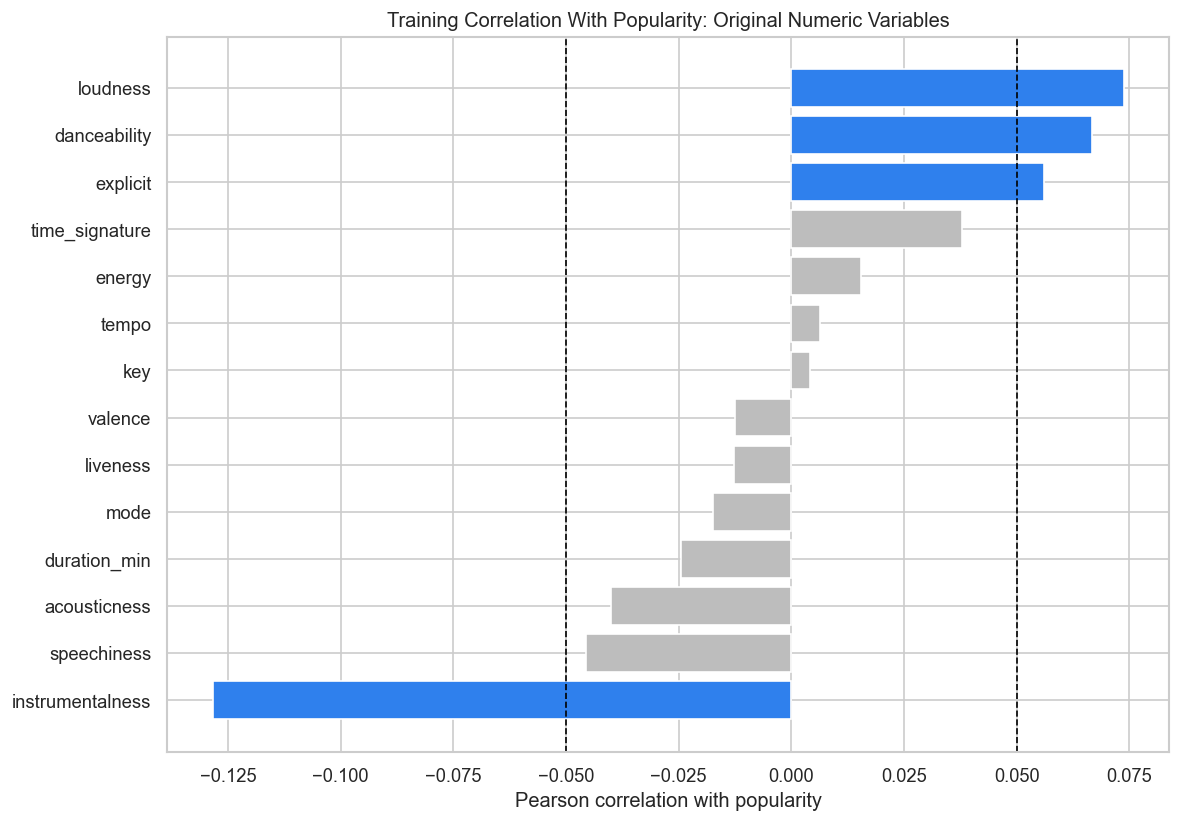

In [6]:
fig, ax = plt.subplots(figsize=(10, 7))
plot_data = numeric_correlation_table.sort_values('training_correlation')
colors = plot_data['decision'].map({'keep': '#2F80ED', 'drop': '#BDBDBD'})

ax.barh(plot_data['numeric_feature'], plot_data['training_correlation'], color=colors)
ax.axvline(LOW_CORRELATION_THRESHOLD, color='black', linestyle='--', linewidth=1)
ax.axvline(-LOW_CORRELATION_THRESHOLD, color='black', linestyle='--', linewidth=1)
ax.set_title('Training Correlation With Popularity: Original Numeric Variables')
ax.set_xlabel('Pearson correlation with popularity')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 4. Multiple-Variable Regression After Filtering

The OLS regression below uses only selected predictors. Selected numeric variables are standardized before regression so their coefficients are comparable. Selected genre indicators are left as binary variables.


In [7]:
ols_numeric = pd.DataFrame(index=X_train.index)
if selected_numeric_features:
    ols_scaler = StandardScaler()
    ols_numeric = pd.DataFrame(
        ols_scaler.fit_transform(X_train_design[selected_numeric_features]),
        columns=selected_numeric_features,
        index=X_train.index,
    )

ols_genres = X_train_design[selected_genre_features].copy()
X_train_ols = pd.concat([ols_numeric, ols_genres], axis=1)
X_train_ols = sm.add_constant(X_train_ols)

ols_model = sm.OLS(y_train.astype(float), X_train_ols.astype(float)).fit()

print(f'OLS training R^2 after filtering:          {ols_model.rsquared:.3f}')
print(f'OLS adjusted training R^2 after filtering: {ols_model.rsquared_adj:.3f}')
print(f'Number of filtered predictors:             {int(ols_model.df_model):,}')


OLS training R^2 after filtering:          0.281
OLS adjusted training R^2 after filtering: 0.281
Number of filtered predictors:             44


In [8]:
coef_table = (
    pd.DataFrame({
        'feature': ols_model.params.drop('const').index,
        'coefficient': ols_model.params.drop('const').values,
        'p_value': ols_model.pvalues.drop('const').values,
    })
    .assign(abs_coefficient=lambda data: data['coefficient'].abs())
    .sort_values('abs_coefficient', ascending=False)
    .drop(columns='abs_coefficient')
)

print('Largest OLS coefficients after filtering:')
display(coef_table.head(25).style.format({'coefficient': '{:.3f}', 'p_value': '{:.2e}'}))


Largest OLS coefficients after filtering:


,feature,coefficient,p_value
5,genre_romance,-30.529,0.00e+00
4,genre_iranian,-29.706,0.00e+00
16,genre_latin,-26.481,1.85e-181
6,genre_k-pop,24.492,1.40e-290
10,genre_jazz,-23.555,2.61e-256
9,genre_pop-film,22.584,5.85e-224
7,genre_detroit-techno,-22.159,2.37e-252
8,genre_chicago-house,-22.098,2.08e-265
14,genre_kids,-20.378,2.27e-217
11,genre_classical,-20.265,1.42e-190


## 5. kNN Regression After Filtering

The kNN model is retrained using only the selected variables. A validation split from the training set chooses `k`; the final model is evaluated once on the untouched 20% test set.


In [9]:
X_selected_train = X_train_design[selected_features]
X_selected_test = X_test_design[selected_features]

X_fit, X_val, y_fit, y_val = train_test_split(
    X_selected_train, y_train, test_size=0.20, random_state=RANDOM_STATE
)

candidate_k = [3, 5, 11, 21, 31, 51, 75, 101, 151, 201, 301]
validation_rows = []

for k in candidate_k:
    candidate_model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=k, weights='distance')),
    ])
    candidate_model.fit(X_fit, y_fit)
    val_pred = candidate_model.predict(X_val)
    validation_rows.append({
        'k': k,
        'validation_r2': r2_score(y_val, val_pred),
        'validation_mae': mean_absolute_error(y_val, val_pred),
        'validation_rmse': np.sqrt(mean_squared_error(y_val, val_pred)),
    })

validation_results = pd.DataFrame(validation_rows).sort_values('validation_mae')
best_k = int(validation_results.iloc[0]['k'])

print(f'Best k by validation MAE: {best_k}')
display(validation_results.style.format({
    'validation_r2': '{:.3f}',
    'validation_mae': '{:.2f}',
    'validation_rmse': '{:.2f}',
}))


Best k by validation MAE: 151


,k,validation_r2,validation_mae,validation_rmse
8,151,0.347,11.74,16.47
9,201,0.349,11.75,16.45
7,101,0.345,11.75,16.50
6,75,0.342,11.77,16.54
10,301,0.349,11.77,16.45
5,51,0.336,11.79,16.61
4,31,0.323,11.89,16.77
3,21,0.309,12.01,16.95
2,11,0.276,12.29,17.34
1,5,0.213,12.83,18.08


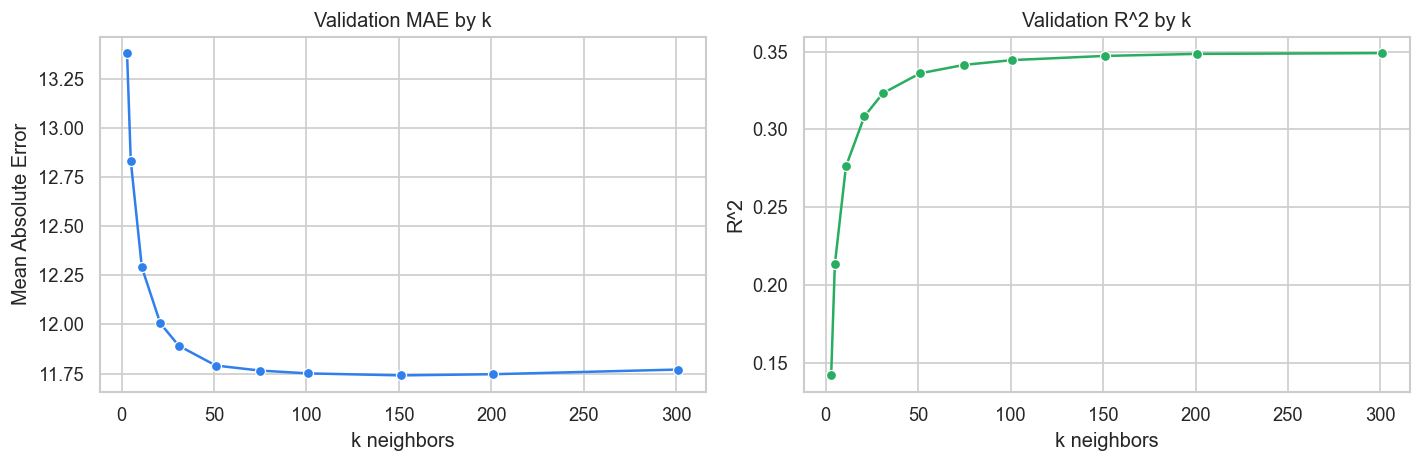

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_df = validation_results.sort_values('k')

sns.lineplot(data=plot_df, x='k', y='validation_mae', marker='o', ax=axes[0], color='#2F80ED')
axes[0].set_title('Validation MAE by k')
axes[0].set_xlabel('k neighbors')
axes[0].set_ylabel('Mean Absolute Error')

sns.lineplot(data=plot_df, x='k', y='validation_r2', marker='o', ax=axes[1], color='#27AE60')
axes[1].set_title('Validation R^2 by k')
axes[1].set_xlabel('k neighbors')
axes[1].set_ylabel('R^2')

plt.tight_layout()
plt.show()


## 6. Final Test-Set Evaluation

The filtered kNN model is trained on the full 80% training set and evaluated on the 20% test set. Because this is regression, the notebook reports R², MAE, RMSE, and the share of predictions within 10 and 20 popularity points.


In [11]:
filtered_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=best_k, weights='distance')),
])

filtered_knn.fit(X_selected_train, y_train)
test_pred = filtered_knn.predict(X_selected_test)
absolute_errors = np.abs(y_test - test_pred)

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_selected_train, y_train)
baseline_pred = baseline.predict(X_selected_test)

metrics = pd.DataFrame([
    {
        'model': f'filtered kNN regression (k={best_k})',
        'test_r2': r2_score(y_test, test_pred),
        'test_mae': mean_absolute_error(y_test, test_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_test, test_pred)),
        'within_10_points': np.mean(absolute_errors <= 10),
        'within_20_points': np.mean(absolute_errors <= 20),
    },
    {
        'model': 'mean baseline',
        'test_r2': r2_score(y_test, baseline_pred),
        'test_mae': mean_absolute_error(y_test, baseline_pred),
        'test_rmse': np.sqrt(mean_squared_error(y_test, baseline_pred)),
        'within_10_points': np.mean(np.abs(y_test - baseline_pred) <= 10),
        'within_20_points': np.mean(np.abs(y_test - baseline_pred) <= 20),
    },
])

display(metrics.style.format({
    'test_r2': '{:.3f}',
    'test_mae': '{:.2f}',
    'test_rmse': '{:.2f}',
    'within_10_points': '{:.1%}',
    'within_20_points': '{:.1%}',
}))


,model,test_r2,test_mae,test_rmse,within_10_points,within_20_points
0,filtered kNN regression (k=151),0.375,11.47,16.17,57.4%,82.5%
1,mean baseline,-0.000,17.11,20.46,31.9%,63.3%


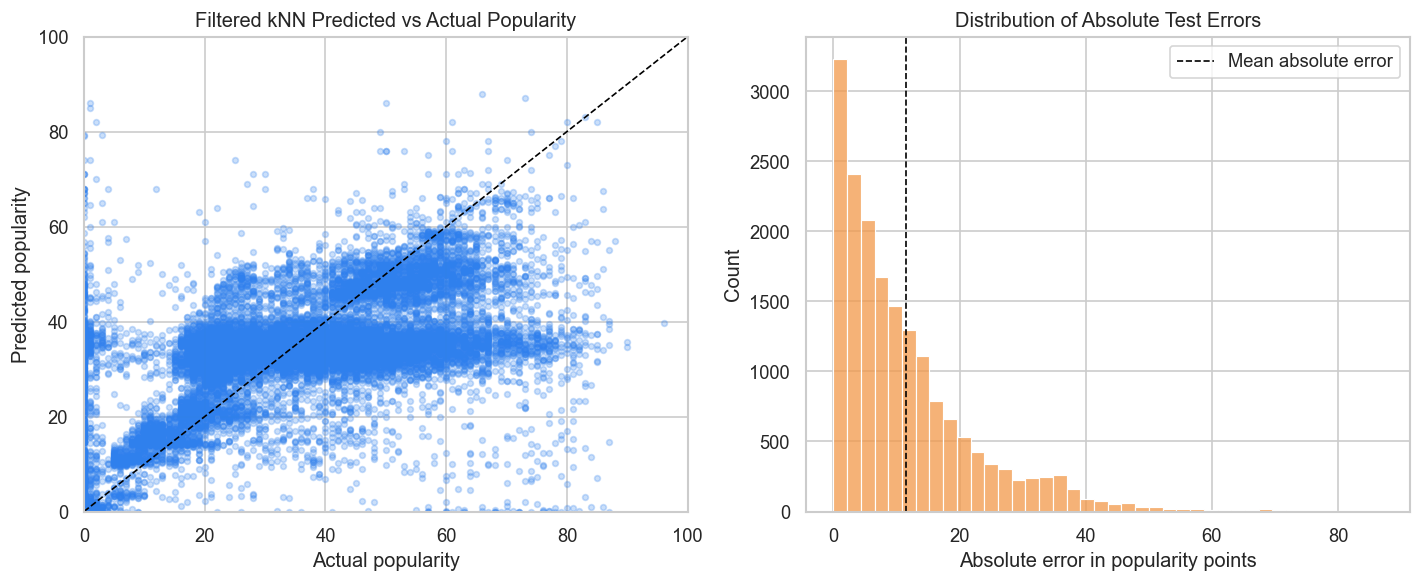

,actual_popularity,predicted_popularity,absolute_error
count,17948.00,17948.00,17948.00
mean,33.24,31.90,11.47
std,20.46,13.98,11.40
min,0.00,0.00,0.00
25%,19.00,27.72,3.31
50%,33.00,34.19,8.07
75%,49.00,38.01,15.68
max,96.00,88.00,87.00


In [12]:
evaluation = pd.DataFrame({
    'actual_popularity': y_test.values,
    'predicted_popularity': test_pred,
    'absolute_error': absolute_errors.values,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(evaluation['actual_popularity'], evaluation['predicted_popularity'], alpha=0.25, s=12, color='#2F80ED')
axes[0].plot([0, 100], [0, 100], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Filtered kNN Predicted vs Actual Popularity')
axes[0].set_xlabel('Actual popularity')
axes[0].set_ylabel('Predicted popularity')
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

sns.histplot(evaluation['absolute_error'], bins=40, ax=axes[1], color='#F2994A')
axes[1].axvline(evaluation['absolute_error'].mean(), color='black', linestyle='--', linewidth=1, label='Mean absolute error')
axes[1].set_title('Distribution of Absolute Test Errors')
axes[1].set_xlabel('Absolute error in popularity points')
axes[1].legend()

plt.tight_layout()
plt.show()

display(evaluation.describe().round(2))


## 7. Conclusion

After deleting very low-correlation predictors, the kNN model becomes more accurate than the earlier audio-only numeric run. The selected variables include a small number of original numeric features plus selected genre indicators. This suggests that removing noisy variables helps kNN distance calculations, and that genre context carries useful popularity information.

The model is still not perfect: popularity depends heavily on non-audio factors such as artist fame, release timing, playlist placement, marketing, and platform dynamics. A better production-grade predictor should add those contextual variables and compare stronger nonlinear models such as Random Forest or gradient boosting.
